In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!unzip -q "/content/drive/MyDrive/angiography_frames.zip" -d /content/dataset/

Mounted at /content/drive


In [2]:
import os, numpy as np, cv2, pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage.filters import sato, apply_hysteresis_threshold
from skimage.morphology import skeletonize

DATASET_ROOT = "/content/dataset/angiography_frames"
LABELS_CSV   = "/content/drive/MyDrive/dev_labels.csv"

CFG = dict(size=512,            # long side after resize (keeps scales consistent)
           bg_sigma=25,         # background (illumination) estimate
           pre_sigma=1.0,       # light denoise before vesselness
           sigmas=(1.5, 2.5, 3.5),
           hi_pct=97.0, lo_pct=92.0,   # window-level hysteresis percentiles
           min_skel=20, border=15, smooth_kernel=(1, 2, 1))

FEATS = ["length", "load", "strength", "contrast", "sharp", "noise", "continuity"]
SIGN  = np.array([1, 1, 1, 1, 1, -1, 1.0])          # noise is a penalty
DEFAULT_W = np.array([0.25, 0.25, 0.10, 0.20, 0.05, 0.10, 0.05])

In [3]:
FEATS = ["length", "load", "strength", "contrast", "sharp", "noise", "continuity",
         "cov", "rves", "rdark", "motion"]
SIGN = np.array([1, 1, 1, 1, 1, -1, 1, 1, 1, 1, -1.0])   # noise & motion are penalties
DEFAULT_W = np.array([0.05, 0.15, 0.03, 0.10, 0.05, 0.05, 0.02, 0.15, 0.10, 0.20, 0.10])
KERNELS = {0: (1, 2, 1), 1: (1, 2, 3, 2, 1)}

In [4]:
def load_gray(p):
    im = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if im is None: raise FileNotFoundError(p)
    s = CFG["size"] / max(im.shape)
    if abs(s - 1) > 1e-3:
        im = cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    return im.astype(np.float32)

def preprocess(img):
    # valid region: drop black collimator bars / borders (they create fake ridges)
    valid = cv2.GaussianBlur(img, (0, 0), 3) > 15
    valid = ndi.binary_erosion(valid, iterations=CFG["border"])
    valid[:8] = valid[-8:] = False; valid[:, :8] = valid[:, -8:] = False
    # relative darkness map: removes uneven illumination, vessels become positive
    bg = cv2.GaussianBlur(img, (0, 0), CFG["bg_sigma"]) + 1.0
    D_raw = (bg - img) / bg
    D = cv2.GaussianBlur(D_raw, (0, 0), CFG["pre_sigma"])
    return D_raw, D, valid

def frame_maps(img):
    D_raw, D, valid = preprocess(img)
    V = sato(D, sigmas=CFG["sigmas"], black_ridges=False)   # Hessian-based ridge filter
    V[~valid] = 0
    return dict(D_raw=D_raw, D=D, valid=valid, V=V)

In [5]:
def window_thresholds(maps):
    pooled = np.concatenate([m["V"][m["valid"]] for m in maps])
    return np.percentile(pooled, CFG["lo_pct"]), np.percentile(pooled, CFG["hi_pct"])

def _clean_skeleton(m, min_len):
    lab, n = ndi.label(m)
    if n:
        areas = ndi.sum(m, lab, range(1, n + 1))
        m = np.isin(lab, 1 + np.where(areas >= 60)[0])
    sk = skeletonize(m)
    lab, n = ndi.label(sk, structure=np.ones((3, 3)))
    sizes = np.array([])
    if n:
        sizes = np.array(ndi.sum(sk, lab, range(1, n + 1)))
        sk = np.isin(lab, 1 + np.where(sizes >= min_len)[0])
        lab, n = ndi.label(sk, structure=np.ones((3, 3)))
        sizes = np.array(ndi.sum(sk, lab, range(1, n + 1))) if n else np.array([])
    return m, sk, sizes

def vessel_mask(V, valid, lo, hi):
    m = apply_hysteresis_threshold(V, lo, hi) & valid
    m, sk, sizes = _clean_skeleton(m, CFG["min_skel"])
    m = m & ndi.binary_dilation(sk, iterations=4)
    return m, sk, sizes

def frame_features(mp, lo, hi):
    """Per-frame-mask features (v1)."""
    V, D, D_raw, valid = mp["V"], mp["D"], mp["D_raw"], mp["valid"]
    m, sk, sizes = vessel_mask(V, valid, lo, hi)
    mp.update(mask=m, skel=sk)
    if sk.sum() < CFG["min_skel"]:
        return dict(length=0, load=0, strength=0, contrast=0, sharp=0, noise=0.05, continuity=0)
    ring   = ndi.binary_dilation(m, iterations=10) & ~ndi.binary_dilation(m, iterations=4) & valid
    bgmask = valid & ~ndi.binary_dilation(m, iterations=10)
    core   = ndi.binary_dilation(sk, iterations=1)
    contrast = D[core].mean() - D[ring].mean()
    gx = cv2.Sobel(D, cv2.CV_32F, 1, 0, ksize=3); gy = cv2.Sobel(D, cv2.CV_32F, 0, 1, ksize=3)
    gm = np.hypot(gx, gy)
    sharp = gm[ndi.binary_dilation(sk, iterations=3)].mean() / (abs(contrast) + 1e-3)
    resid = D_raw - cv2.GaussianBlur(D_raw, (0, 0), 2)
    r = resid[bgmask]
    noise = 1.4826 * np.median(np.abs(r - np.median(r)))
    load = float(np.clip(V[m] - lo, 0, None).sum())
    big = sizes[sizes >= 60].sum()
    return dict(length=float(sk.sum()), load=load, strength=float(V[sk].mean()),
                contrast=float(contrast), sharp=float(sharp), noise=float(noise),
                continuity=float(big / sizes.sum()))

def persistent_features(maps, lo):
    """v2: measure every frame on ONE fixed vessel tree (stable, motion-tolerant)."""
    valid = maps[0]["valid"]
    Vmean = np.mean([m["V"] for m in maps], axis=0)
    p_lo, p_hi = np.percentile(Vmean[valid], 90), np.percentile(Vmean[valid], 97)
    P = apply_hysteresis_threshold(Vmean, p_lo, p_hi) & valid
    P, Ps, _ = _clean_skeleton(P, 30)
    n = len(maps)
    if Ps.sum() < 30:
        return np.zeros((n, 4)), Ps
    Pd = ndi.binary_dilation(P, iterations=2)
    ring = ndi.binary_dilation(P, iterations=10) & ~ndi.binary_dilation(P, iterations=4) & valid
    roi_motion = ndi.binary_dilation(P, iterations=6)
    out = np.zeros((n, 4))
    for i, mp in enumerate(maps):
        Vmax = ndi.maximum_filter(mp["V"], size=7)        # tolerate cardiac motion
        Dmax = ndi.maximum_filter(mp["D"], size=5)
        cov   = np.mean(Vmax[Ps] > lo)                    # fraction of the tree that is visible
        rves  = Vmax[Ps].mean()                           # vesselness along the tree
        rdark = Dmax[Ps].mean() - mp["D"][ring].mean()    # opacification vs local background
        nb = [abs(mp["D"] - maps[j]["D"])[roi_motion].mean() for j in (i - 1, i + 1) if 0 <= j < n]
        out[i] = [cov, rves, rdark, np.mean(nb)]
    return out, Ps

In [6]:
FEATS_FINAL = ["load", "strength", "contrast"]

def zscore(x):
    x = np.asarray(x, float); med = np.median(x)
    s = 1.4826 * np.median(np.abs(x - med))
    if s < 1e-9: s = x.std()
    if s < 1e-9: return np.zeros_like(x)
    return np.clip((x - med) / s, -3, 3)

def plateau_center(s, thr=0.0):
    """Pick the middle of the longest run of frames at-or-above the window's
    median score, instead of the single highest-scoring frame. A sustained
    good stretch is more trustworthy than a single spike, which could be
    noise, reflux, or a one-frame segmentation artifact."""
    good = s >= thr
    runs, i = [], 0
    while i < len(good):
        if good[i]:
            j = i
            while j < len(good) and good[j]: j += 1
            runs.append((i, j)); i = j
        else:
            i += 1
    if not runs:
        return int(np.argmax(s))
    i0, i1 = max(runs, key=lambda r: r[1] - r[0])
    seg = s[i0:i1]
    w = np.exp(seg - seg.max()); w /= w.sum()
    return int(round(i0 + w.dot(np.arange(i1 - i0))))

def compute_window_features(window):
    imgs = []
    for f in window:
        if isinstance(f, str): imgs.append(load_gray(f))
        else:
            f = np.asarray(f, np.float32); s = CFG["size"] / max(f.shape)
            imgs.append(cv2.resize(f, None, fx=s, fy=s, interpolation=cv2.INTER_AREA))
    maps = [frame_maps(i) for i in imgs]
    lo, hi = window_thresholds(maps)
    F1 = np.array([[frame_features(mp, lo, hi)[k] for k in FEATS[:7]] for mp in maps])
    F2, Ps = persistent_features(maps, lo)
    return np.hstack([F1, F2]), imgs, maps, Ps

def score_from_features(F):
    idx = {f: FEATS.index(f) for f in FEATS_FINAL}
    return sum(zscore(F[:, idx[f]]) for f in FEATS_FINAL)

def select_best_frame(window, return_all=False):
    """window: list of paths OR grayscale arrays (any N). Returns (best_index, scores)."""
    F, imgs, maps, Ps = compute_window_features(window)
    s = score_from_features(F)
    best = plateau_center(s, thr=0.0)
    return (best, s, F, imgs, maps, Ps) if return_all else (best, s)

In [7]:
labels = pd.read_csv(LABELS_CSV)

def get_window_paths(root, case_id, row):
    out = []
    for i in range(int(row.window_start), int(row.window_end) + 1):
        p = os.path.join(root, case_id, f"frame_{i:03d}.png")
        if os.path.exists(p): out.append((i, p))
    return out

cache = {}
for _, row in labels.iterrows():
    items = get_window_paths(DATASET_ROOT, row.case_id, row)
    if not items: print("missing:", row.case_id); continue
    F, _, _, _ = compute_window_features([p for _, p in items])
    cache[row.case_id] = dict(nums=np.array([n for n, _ in items]), F=F, gt=int(row.best_frame))
print("cached", len(cache), "cases")

cached 10 cases


In [8]:
def rank_of_gt(c, s):
    order = np.argsort(-s)
    gi = int(np.where(c["nums"] == c["gt"])[0][0])
    return int(np.where(order == gi)[0][0])

def evaluate(cache):
    errs, ranks = [], []
    for k, c in cache.items():
        s = score_from_features(c["F"])
        pred = int(c["nums"][plateau_center(s)])
        errs.append(abs(pred - c["gt"])); ranks.append(rank_of_gt(c, s))
    errs, ranks = np.array(errs), np.array(ranks)
    return dict(mae=errs.mean(), exact=(errs == 0).mean(), within2=(errs <= 2).mean(),
                rank=ranks.mean(), errs=errs)

r = evaluate(cache)
print(f"FINAL (combo B, plateau-center)  MAE={r['mae']:.2f}  exact={r['exact']:.0%}  "
      f"within±2={r['within2']:.0%}  meanRank={r['rank']:.2f}  errs={r['errs']}")

FINAL (combo B, plateau-center)  MAE=2.30  exact=0%  within±2=80%  meanRank=4.00  errs=[1 1 7 5 2 2 1 2 1 1]


In [10]:
print(f"{'case':14s} {'pred':>5s} {'gt':>5s} {'err':>4s} {'rankGT':>7s}")
for k, c in cache.items():
    s = score_from_features(c["F"])
    p = int(c["nums"][plateau_center(s)])
    print(f"{k:14s} {p:5d} {c['gt']:5d} {abs(p - c['gt']):4d} {rank_of_gt(c, s):7d}")

case            pred    gt  err  rankGT
case_dev_001      46    47    1       0
case_dev_002     100    99    1       3
case_dev_003      25    32    7       9
case_dev_004      33    38    5      10
case_dev_005      21    23    2       4
case_dev_006      31    29    2       4
case_dev_007      17    16    1       4
case_dev_008      23    25    2       2
case_dev_009      18    17    1       3
case_dev_010      19    18    1       1


In [14]:
def explain_window(case_id, gt=None):
    row = labels[labels.case_id == case_id].iloc[0]
    items = get_window_paths(DATASET_ROOT, case_id, row)
    nums = [n for n, _ in items]
    best, s, F, imgs, maps, Ps = select_best_frame([p for _, p in items], return_all=True)
    gt = gt if gt is not None else int(row.best_frame)

    n = len(imgs); cols = 5; rows = int(np.ceil(n / cols))
    fig = plt.figure(figsize=(16, 3.2 * rows + 4))
    gs = fig.add_gridspec(rows + 1, cols, height_ratios=[1] * rows + [1.2])

    for i in range(n):
        ax = fig.add_subplot(gs[i // cols, i % cols])
        ax.imshow(imgs[i], cmap="gray")
        ov = np.zeros(imgs[i].shape + (4,)); ov[maps[i]["skel"]] = (1, .2, .2, .9)
        ax.imshow(ov)
        tag = "  (GT)" if gt == nums[i] else ""
        ax.set_title(f"Frame {nums[i]}{tag}\nscore {s[i]:.2f}", fontsize=10,
                     color="green" if i == best else "black",
                     fontweight="bold" if i == best else "normal")
        ax.axis("off")

    axc = fig.add_subplot(gs[rows, 0:3])
    good = s >= 0.0
    axc.plot(nums, s, "o-", color="steelblue")
    axc.fill_between(nums, s.min(), s.max(), where=good, color="steelblue", alpha=0.12,
                      label="plateau region (score ≥ median)")
    axc.axvline(nums[best], color="green", lw=2, label=f"predicted = {nums[best]}")
    axc.axvline(gt, color="red", ls=":", lw=2, label=f"ground truth = {gt}")
    axc.set_xlabel("frame number"); axc.set_ylabel("combined score (load+strength+contrast)")
    axc.set_title(f"{case_id} — score vs frame"); axc.legend(fontsize=8)

    axv = fig.add_subplot(gs[rows, 3:5])
    axv.imshow(maps[best]["V"], cmap="magma"); axv.axis("off")
    axv.set_title(f"Vesselness map — selected frame {nums[best]}")

    plt.tight_layout()
    plt.savefig(f"/content/{case_id}_explain.png", dpi=120, bbox_inches="tight")   # <-- moved inside, uses the function's own case_id
    plt.show()

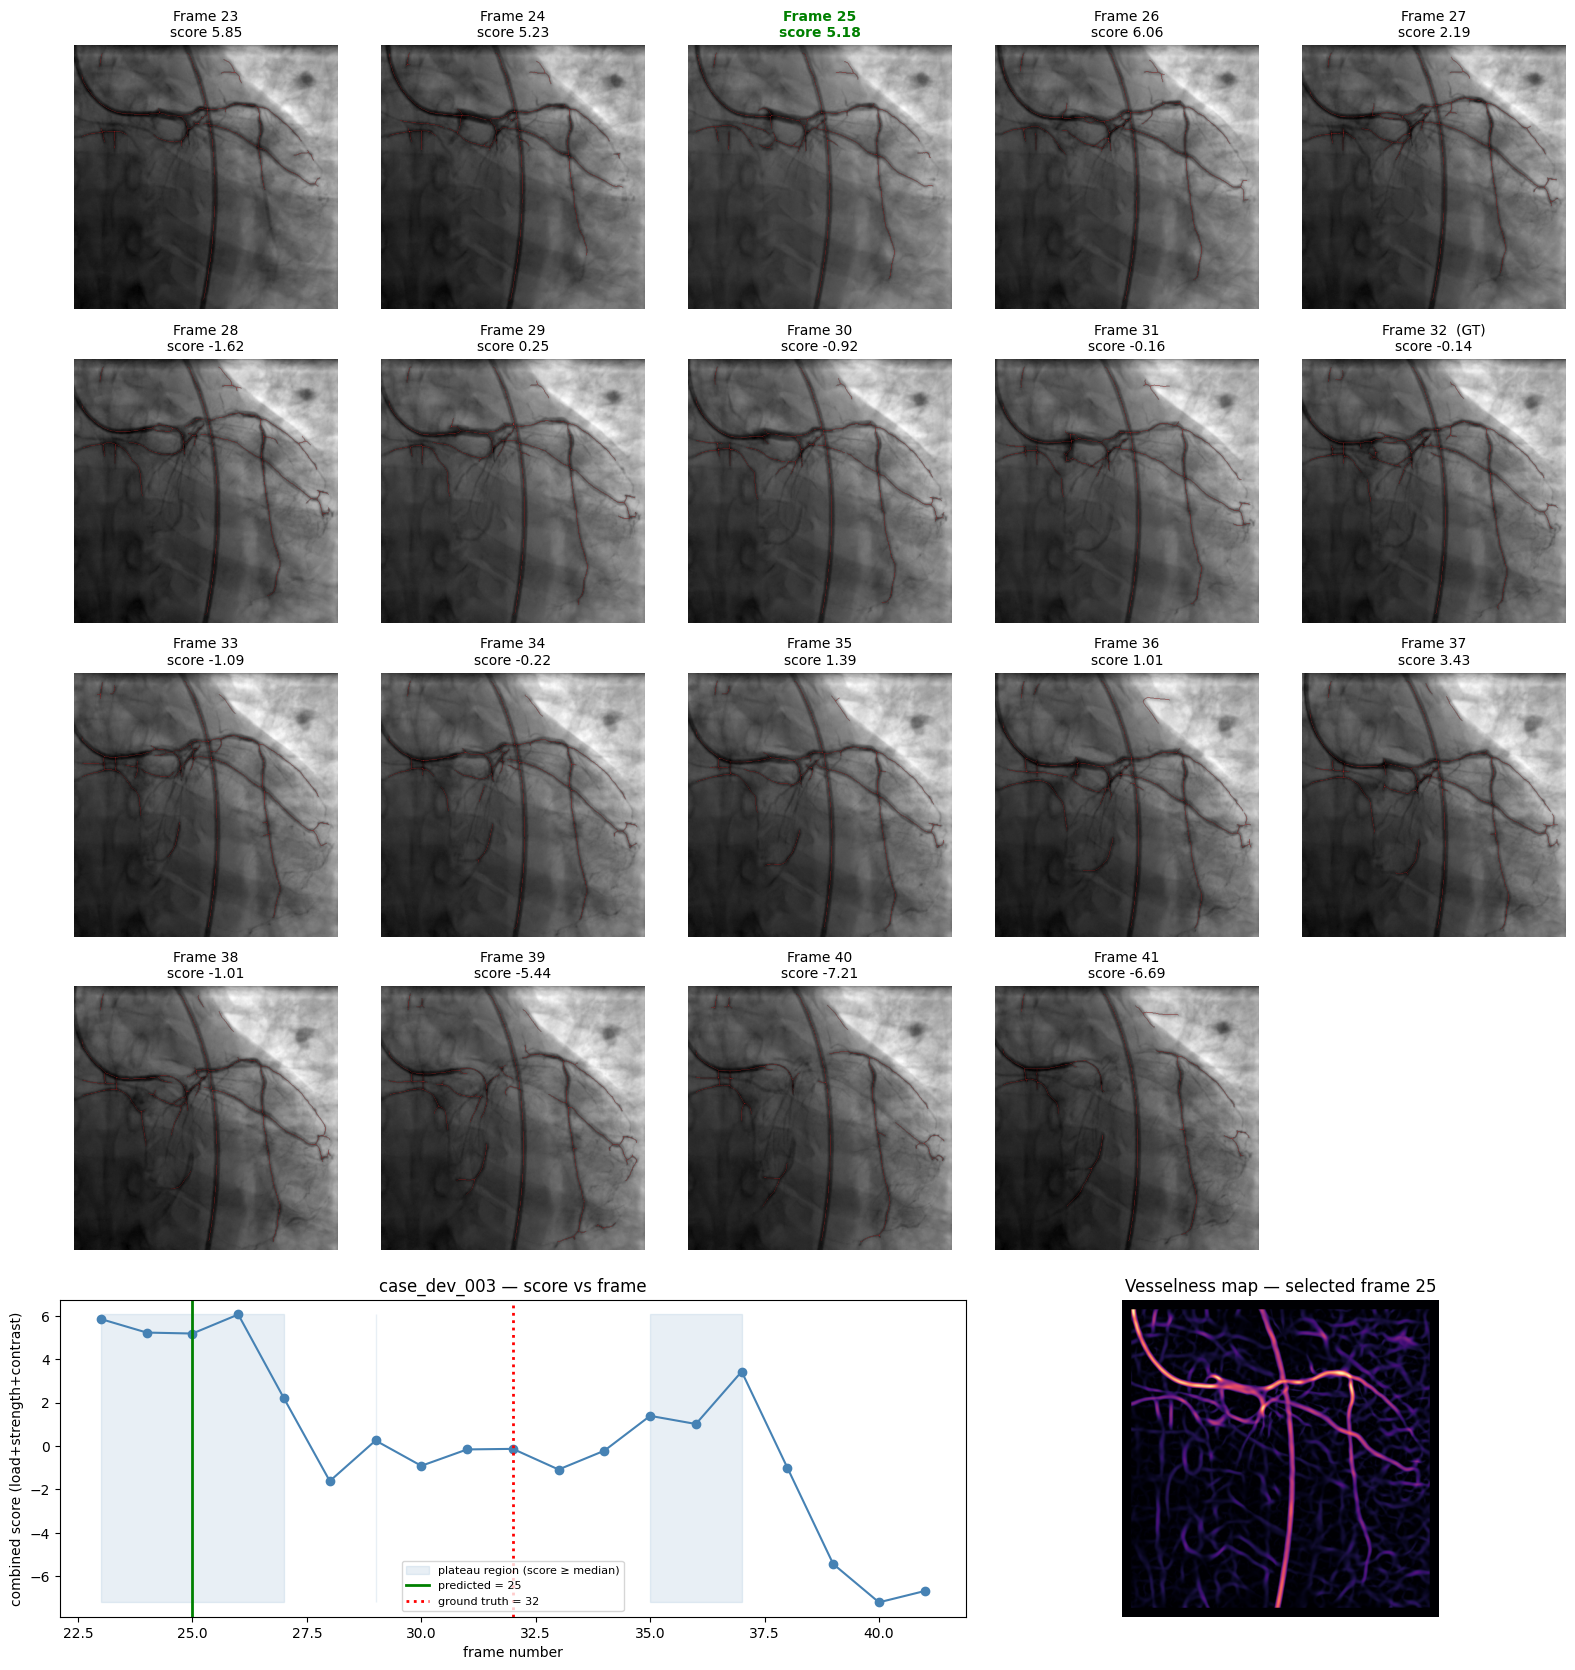

In [15]:
explain_window("case_dev_003")

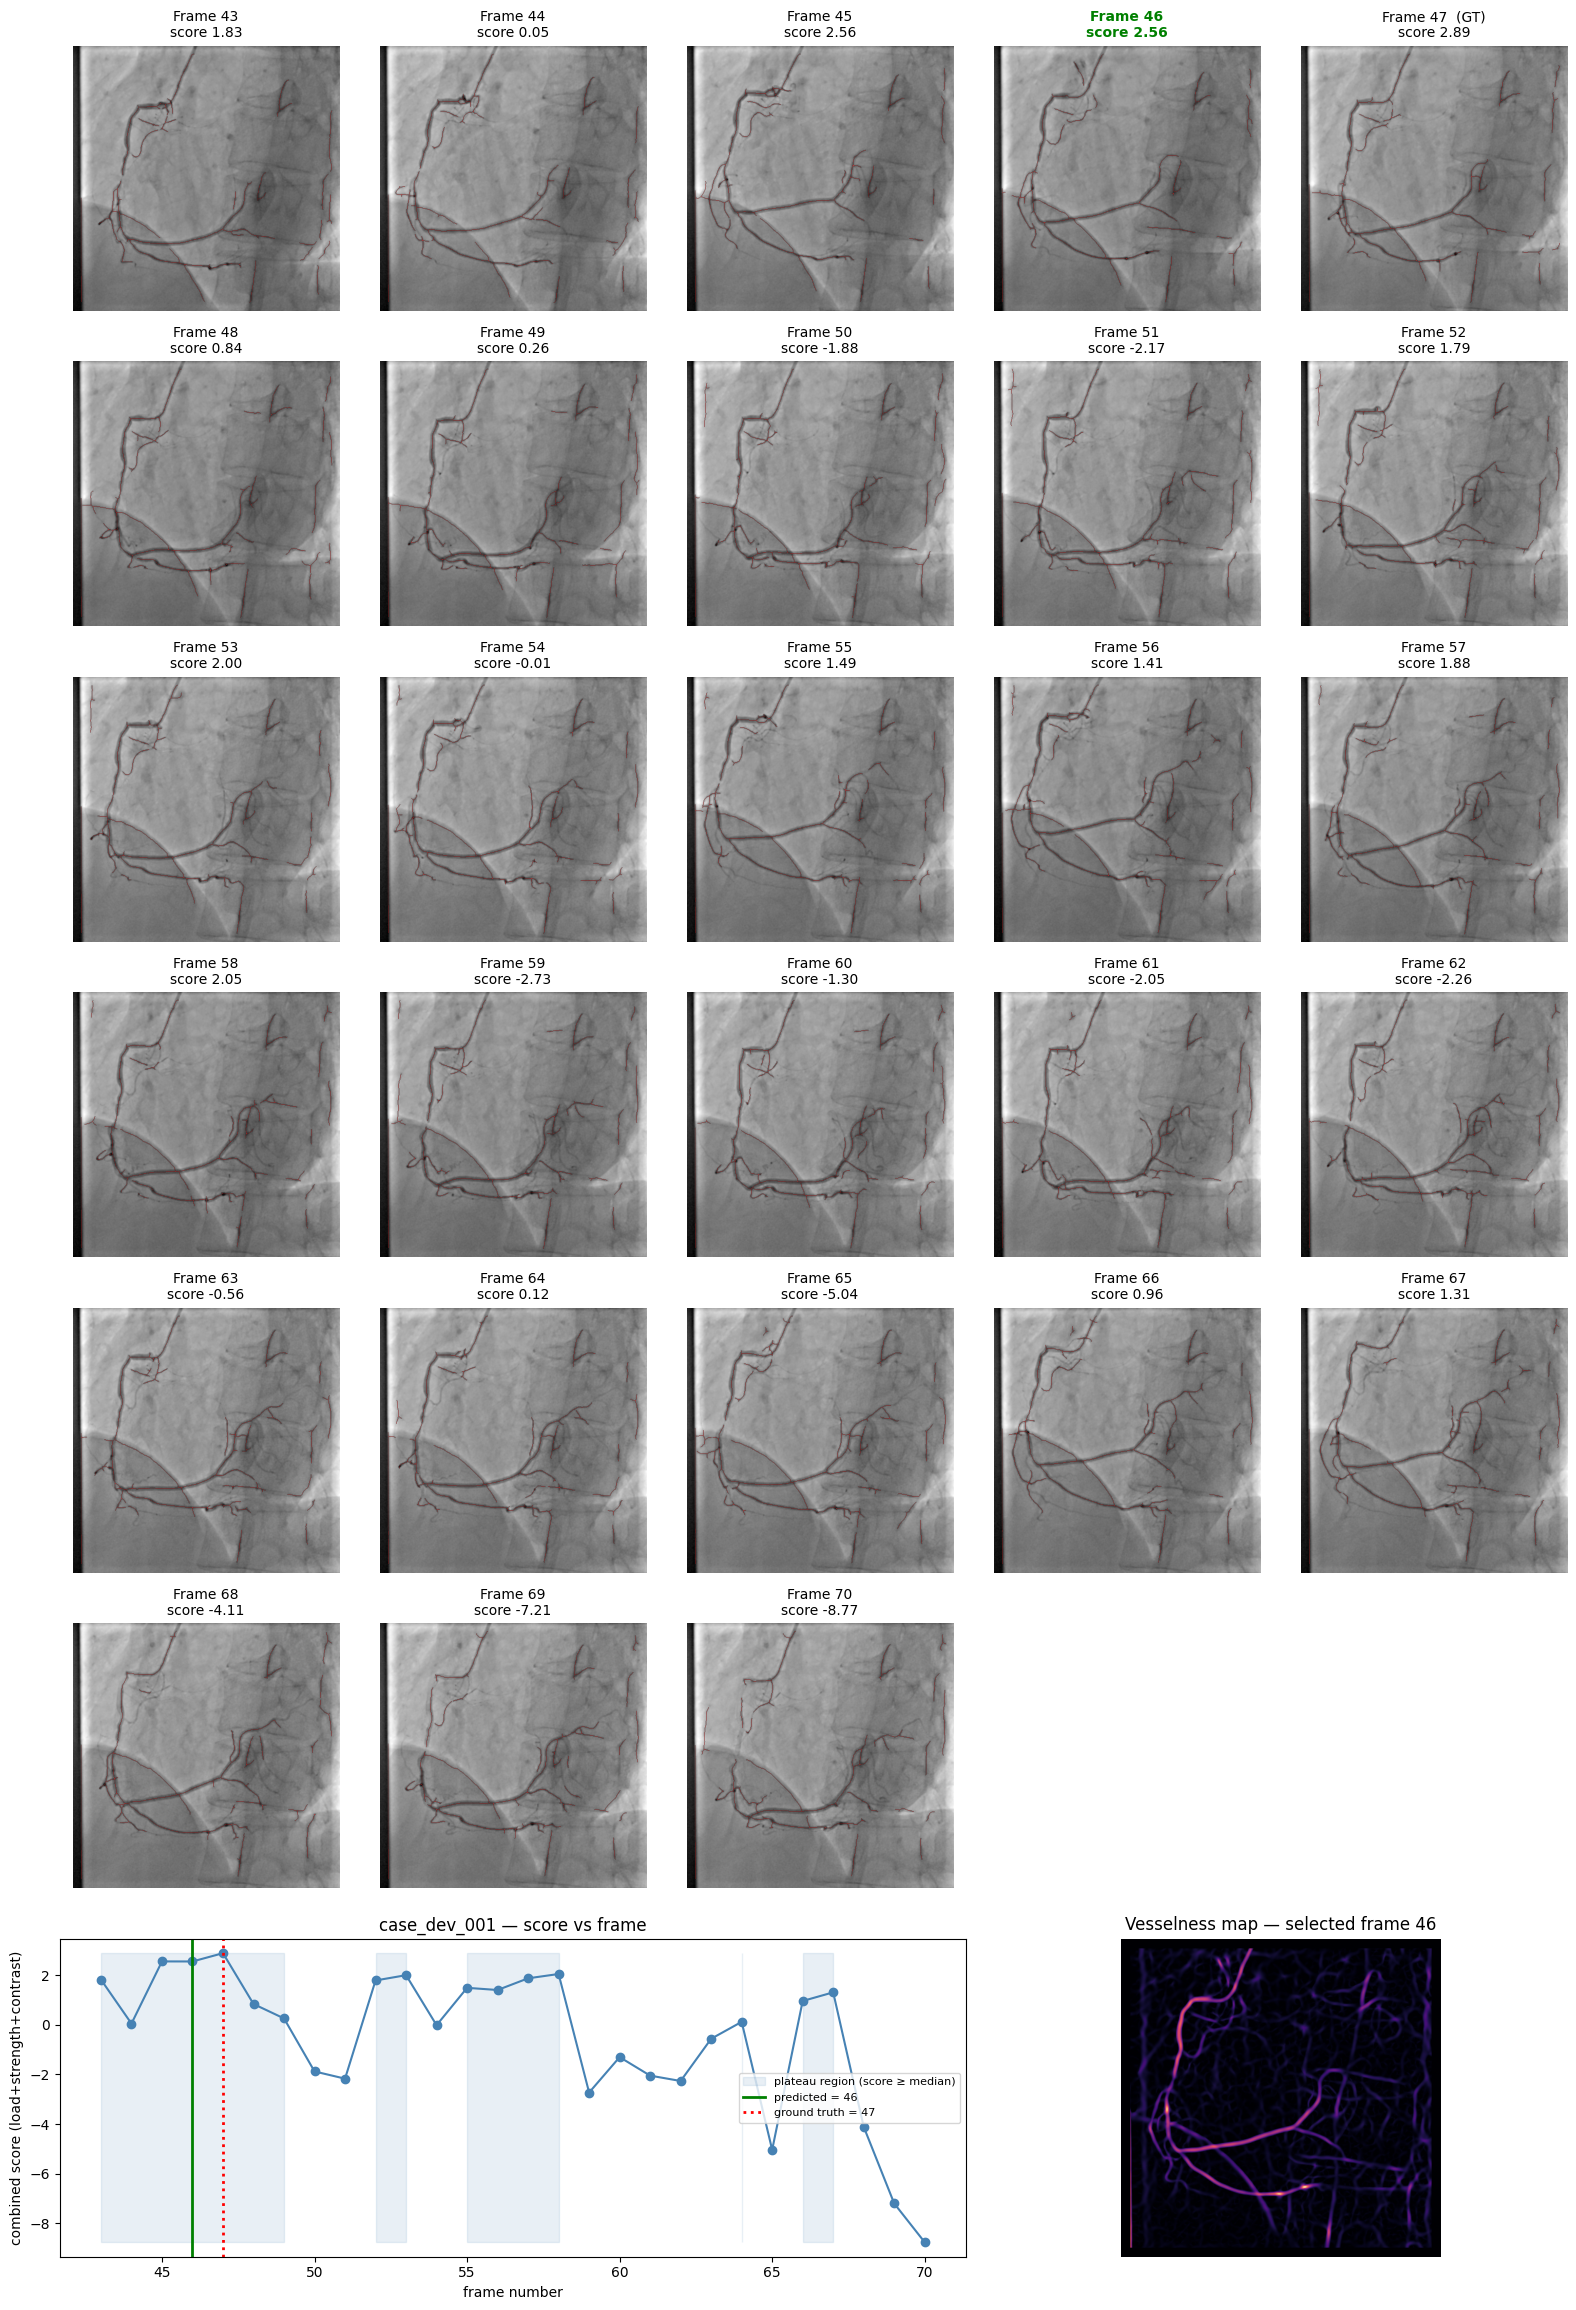

In [17]:
explain_window("case_dev_001")

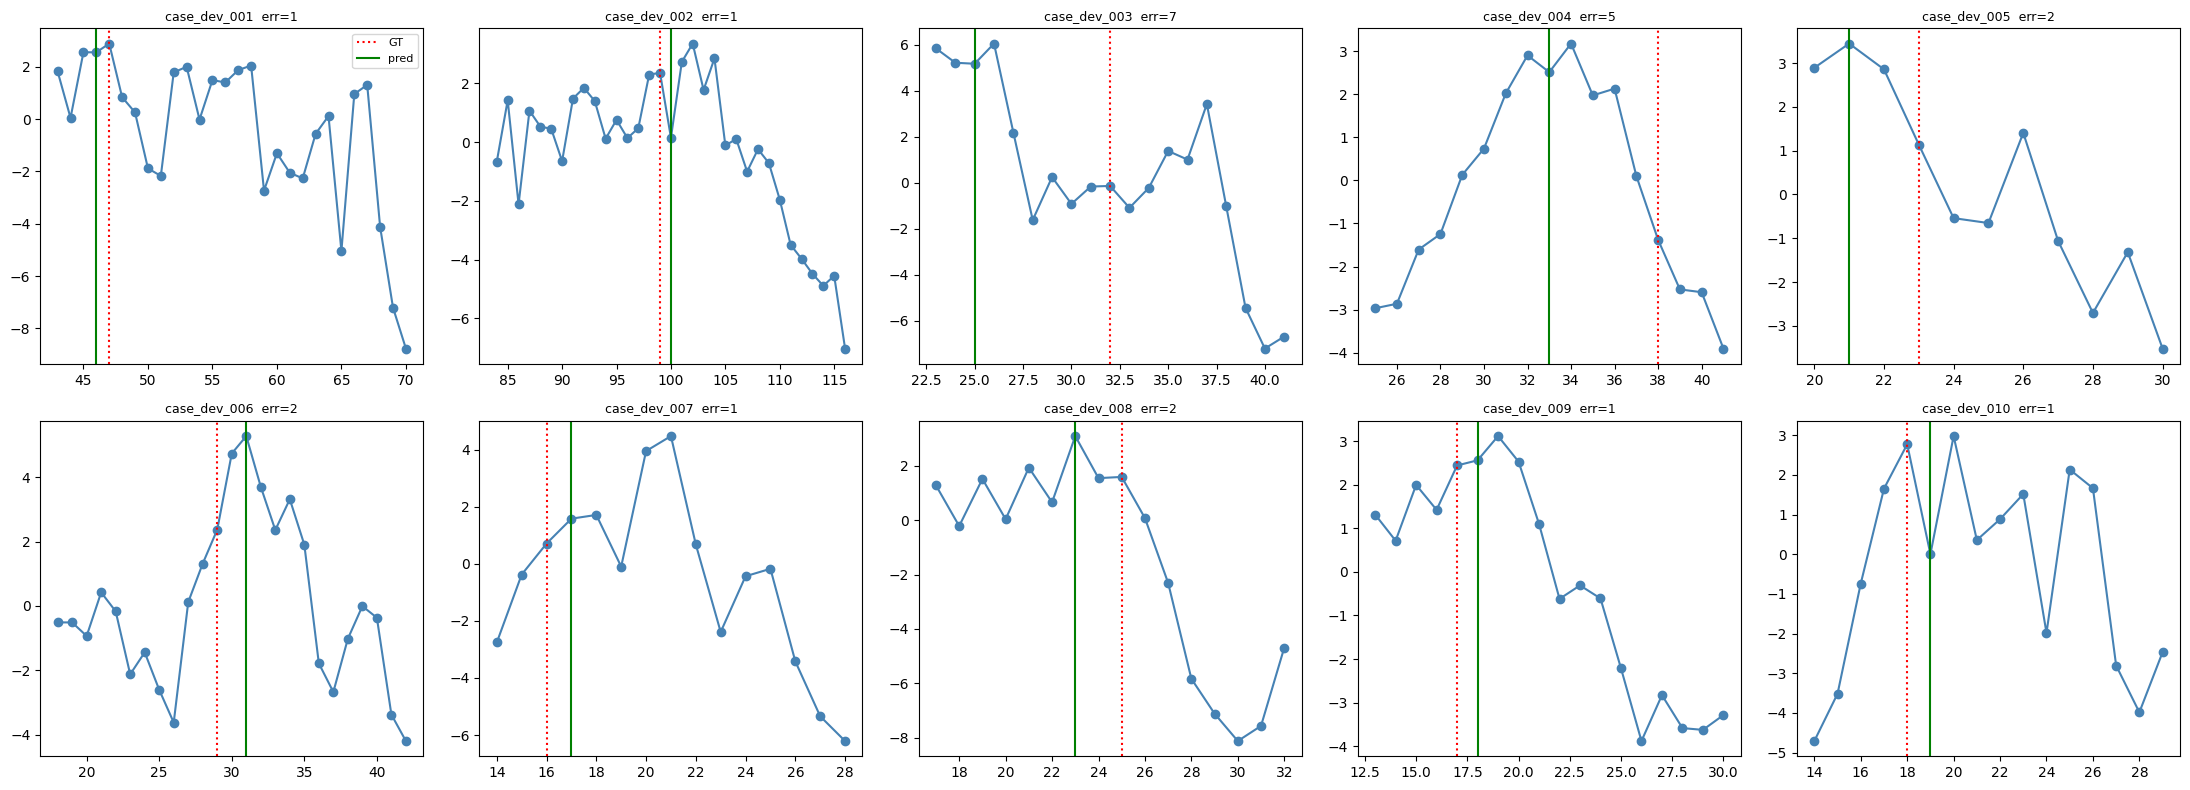

In [20]:
fig, axs = plt.subplots(2, 5, figsize=(22, 8)); axs = axs.ravel()
for ax, (k, c) in zip(axs, cache.items()):
    s = score_from_features(c["F"])
    pred = c["nums"][plateau_center(s)]
    ax.plot(c["nums"], s, "o-", color="steelblue")
    ax.axvline(c["gt"], color="red", ls=":", label="GT")
    ax.axvline(pred, color="green", label="pred")
    ax.set_title(f"{k}  err={abs(int(pred)-c['gt'])}", fontsize=9)
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("/content/all_cases_overview.png", dpi=120, bbox_inches="tight")
plt.show()